## Setup (takes ~15 minutes)

Note: you should run this notebook on an A100 Colab instance.

`ppd_sharpdepth` is the model we trained.



Download, clone submodules, install dependencies:

In [1]:
!git config --global url."https://github.com/".insteadOf git@github.com:
!git clone https://github.com/anthonyceponis/mvp-depth-refinement
%cd mvp-depth-refinement
!source ./setup.sh # installs deps and clones submodules

Cloning into 'mvp-depth-refinement'...
remote: Enumerating objects: 3080, done.
remote: Counting objects: 100% (346/346), done.
remote: Compressing objects: 100% (194/194), done.
remote: Total 3080 (delta 211), reused 251 (delta 149), pack-reused 2734 (from 2)
Receiving objects: 100% (3080/3080), 6.57 MiB | 15.55 MiB/s, done.
Resolving deltas: 100% (1746/1746), done.
/content/mvp-depth-refinement
Submodule 'submodules/ARKitScenes' (git@github.com:anthonyceponis/ARKitScenes.git) registered for path 'submodules/ARKitScenes'
Submodule 'submodules/Depth-Anything' (git@github.com:andrew-healey/Depth-Anything.git) registered for path 'submodules/Depth-Anything'
Submodule 'submodules/MiDaS' (https://github.com/andrew-healey/MiDaS) registered for path 'submodules/MiDaS'
Submodule 'submodules/PatchRefiner' (git@github.com:OHo315/PatchRefiner) registered for path 'submodules/PatchRefiner'
Submodule 'submodules/SharpDepth' (git@github.com:andrew-healey/SharpDepth.git) registered for path 'submodu

## Infer the model (restart first)

In [2]:
import sys
sys.path.insert(0, '/content/mvp-depth-refinement/submodules/UniDepth')

In [3]:
%cd /content/mvp-depth-refinement
import unidepth

/content/mvp-depth-refinement


In [4]:
%env XFORMERS_DISABLED=1
%env MIDAS_PATH=/content/submodules/MiDaS

from ppd_sharpdepth.depth_estimators import get_depth_estimator_fn, ModelArchitecture
from ppd_sharpdepth.preprocessors import MarigoldPreProcessor

import torch
device = torch.device("cuda")
float_dtype = torch.bfloat16

ppd_sharpdepth_model = get_depth_estimator_fn(ModelArchitecture.sharpdepth_ppd_controlnet_unidepth, device, float_dtype, "hf://andrew-healey/sharpdepth:controlnet_edge_loss_unidepth")
ppd_model = get_depth_estimator_fn(ModelArchitecture.pixelperfectdepth_unidepth, device, float_dtype, "andrew-healey/sharpdepth")
unidepth_model = get_depth_estimator_fn(ModelArchitecture.unidepth, device, float_dtype, "lpiccinelli/unidepth-v1-vitl14")

env: XFORMERS_DISABLED=1
env: MIDAS_PATH=/content/submodules/MiDaS


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/content/mvp-depth-refinement/submodules/UniDepth/unidepth/utils/chamfer_distance.py:9: UserWarning: !! To run evaluation you need KNN. Please compile KNN: `cd unidepth/ops/knn with && bash compile.sh`.
  warnings.warn(
/content/mvp-depth-refinement/submodules/UniDepth/unidepth/layers/nystrom_xformers.py:14: FutureWarning: xformers.components is deprecated and is not maintained anymore. It might be removed in a future version of xFormers 
  from xformers.components.attention import Attention, AttentionConfig, register_attention
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secr

config.json:   0%|          | 0.00/912 [00:00<?, ?B/s]

Not loading pretrained weights for backbone


/usr/local/lib/python3.12/dist-packages/xformers/components/attention/base.py:40: FutureWarning: NystromAttention() is deprecated and is not maintained anymore. It might be removed in a future version of xFormers
  deprecated_function(self)


...

config.json:   0%|          | 0.00/719 [00:00<?, ?B/s]

The config attributes {'feature_extractor': ['transformers', 'CLIPImageProcessor'], 'image_encoder': [None, None], 'requires_safety_checker': False, 'safety_checker': [None, None]} were passed to SharpDepthPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'feature_extractor': ['transformers', 'CLIPImageProcessor'], 'image_encoder': [None, None], 'requires_safety_checker': False, 'safety_checker': [None, None]} are not expected by SharpDepthPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Expected types for align_depth_least_square: (typing.Callable, <class 'NoneType'>), got <class 'bool'>.
Expected types for noise_aware_latent_noise_scale: (<class 'float'>,), got <class 'int'>.


Not loading pretrained weights for backbone
Not loading pretrained weights for backbone


In [6]:
from PIL import Image
import numpy as np
import torch

!wget https://raw.githubusercontent.com/anthonyceponis/mvp-depth-refinement/refs/heads/main/images/example_nyu_image.png

img = Image.open("/content/rgb_1180.png")
rgb_int_1chw = torch.from_numpy(np.array(img)).permute(2,0,1)[None,...].int()
print(rgb_int_1chw.dtype)

--2026-01-07 03:23:40--  https://raw.githubusercontent.com/anthonyceponis/mvp-depth-refinement/refs/heads/main/images/example_nyu_image.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 355331 (347K) [image/png]
Saving to: ‘example_nyu_image.png.1’

example_nyu_image.p 100%[===================>] 347.00K  --.-KB/s    in 0.003s  

2026-01-07 03:23:40 (119 MB/s) - ‘example_nyu_image.png.1’ saved [355331/355331]

torch.int32


In [7]:

ppd_sharpdepth_depth_map_hw = ppd_sharpdepth_model(rgb_int_1chw, MarigoldPreProcessor)
ppd_depth_map_hw = ppd_model(rgb_int_1chw, MarigoldPreProcessor)
unidepth_depth_map_hw = unidepth_model(rgb_int_1chw, MarigoldPreProcessor)


Unidepth:


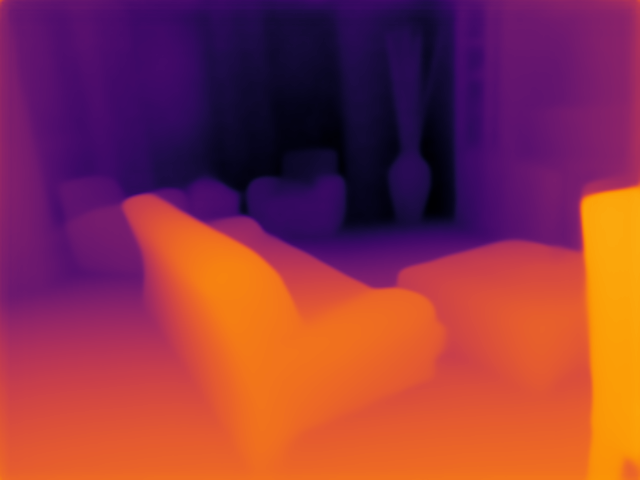

Unidepth refined with PPD-SharpDepth:


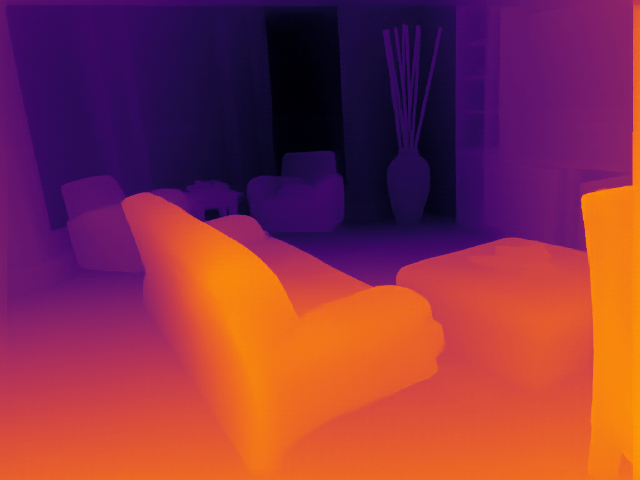

PPD:


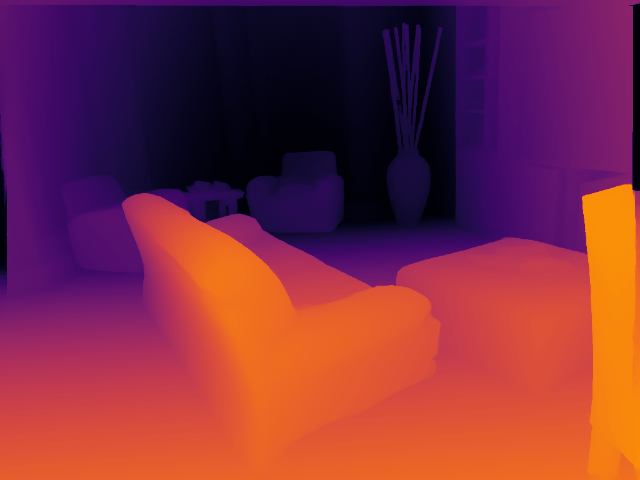

In [8]:

from google.colab.patches import cv2_imshow
from ppd_sharpdepth.sharpdepth.util.image_util import colorize_depth_maps, chw2hwc

for depth_map,model_name in [(unidepth_depth_map_hw,"Unidepth"),(ppd_sharpdepth_depth_map_hw,"Unidepth refined with PPD-SharpDepth"),(ppd_depth_map_hw,"PPD")]:
  depth_map_np = depth_map.cpu().numpy()
  print(f"{model_name}:")
  colorized = colorize_depth_maps(depth_map_np[None],0, depth_map_np.max(), cmap="inferno_r").squeeze()
  cv2_imshow((chw2hwc(colorized)*255).astype(np.uint8)[...,::-1])